# $\color{orange}{\text{Chapter 6 of "Statistical Physics"}}$
# $\color{orange}{\text{Paragraphs: 6.5 (Translational Entropy of a classical gas); 6.6 (Maxwell distributions) and 6.7 (Real gases)}}$


Author: Jan Ryckebusch (notebook version September 2019, major additions October 2021)

 - This notebook produces plots of the intermolecular Lennard-Jones interaction and Lennard-Jones force for some prototypical molecules

Definition of Lennard-Jones potential: $ U_{LJ}(r_{12}) = U_0 \, \left[ \left(
\frac{r_0}{r_{12}} \right)^{12} - 2 \, \left( \frac{r_0}{r_{12}} \right)^6
\right] $

       
- This notebook computes the temperature-dependent $B_2^*(T)$ quantity of Equation (6.103) *(second virial coefficient for Lennard-Jones potential in dimensionless units)*
       
$B_2^*(T)= \frac {B_2(T)} {\frac{2}{3} \pi r_{0}^{3}} = $
$3  \int _0 ^{+\infty} dX \; X^2 \biggl[ 1 - e^{\frac {-U_0} {kT} \left[ X^{-12} - 2 X^{-6} \right]} \biggr] $
with the dimensionless quantity $X \equiv \frac{r_{12}}{r_0}  \; $.


 - Interesting additional information about the connection of Lennard-Jones potentials (including values for $r_0,U_0$) and data:
 https://www.ijsr.net/archive/v6i10/ART20177192.pdf
  
 - The function $\lambda \left(r_{12} \right) = \exp - \beta U_{LJ}(r_{12}) - 1$ is often used in computations ; the function can often be approximated by: $\lambda \left(r_{12}  \ge r_0 \right) \approx - \beta U_{LJ}(r_{12})$ en $\lambda \left(r_{12}  \le r_0 \right) \approx -1$ - a figure is included to evaluate the quality of this approximation


In [ ]:
from scipy import integrate # integration routines from scipy (Scientific Python)
import math as m
import numpy as np
import pylab as pl   # import the plotting routines
import seaborn as sns # seaborn for managing color palette

sns.set_palette("dark") # other options: deep, muted, pastel, bright, dark, and colorblind.
#
# change some plot parameters ... things look better
params = {'legend.fontsize': 'x-large',
          'axes.linewidth' : 2,
#          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
          'xtick.major.width' : 3,
          'xtick.major.size'  : 12,
          'ytick.major.width' : 3,
          'ytick.major.size'  : 12,
          'xtick.major.pad'  : 10,
          'xtick.minor.width' : 2,
          'xtick.minor.size'  : 6,
          'ytick.minor.width' : 2,
          'ytick.minor.size'  : 6,}
pl.rcParams.update(params)
pl.rc("font",family="serif",weight='bold')
lines = ["-","--","-.",":"]

## $\color{orange}{\text{6.7 Reele gassen}}$

In [ ]:
def LennardJones(U0,r0,rrange):
  return U0*(np.power(r0/rrange,12.)-np.power(r0/rrange,6.))

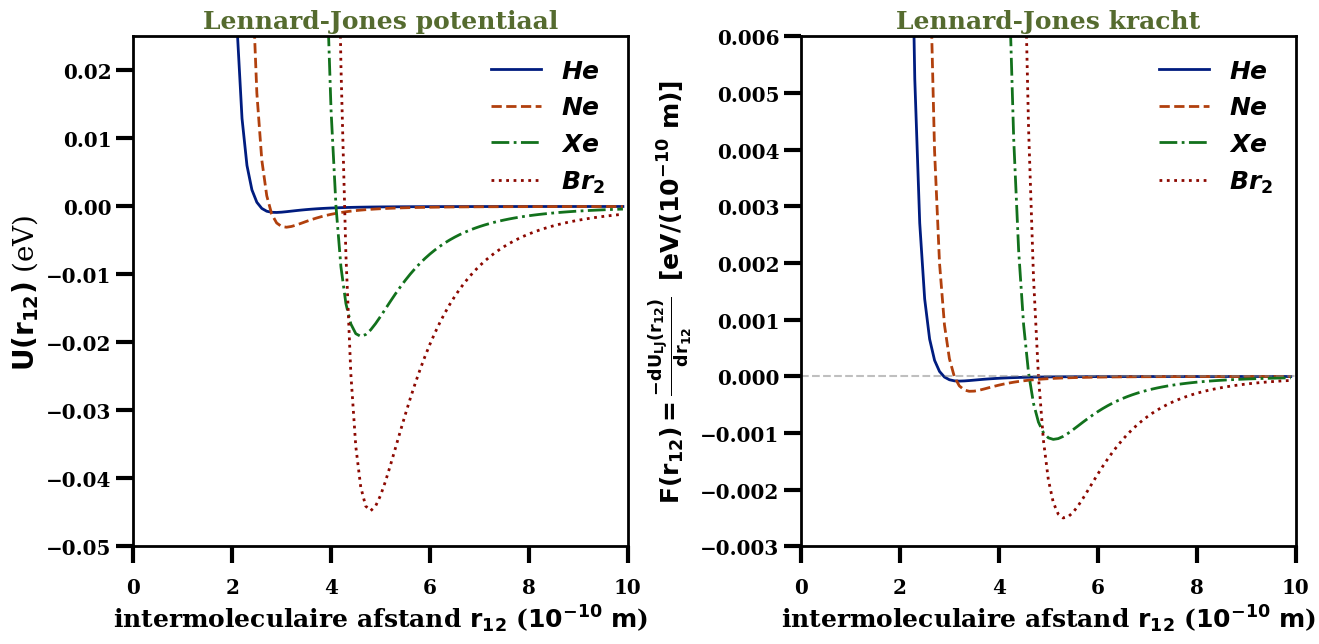

In [ ]:
# create figure with intermolecular Lennard-Jones potential and force for various moleculues
U0L=[3.52e-03,1.22e-02,7.64e-02,1.79e-01] # U0 in eV
r0L=[2.56,2.75,4.10,4.27]                 # r0 in 10^{-10} m
labL=['$He$','$Ne$','$Xe$','$Br_{2}$']
rrange=np.arange(0.2,10,0.1)


figLJ=pl.figure(figsize=(15,7.5))
figLJ.tight_layout()
axLJ=figLJ.add_subplot(121)
axLJ2=figLJ.add_subplot(122)
axLJ.axis([0.,10.,-0.05,0.025])
axLJ2.axis([0.,10.,-0.003,0.006])
figLJ.subplots_adjust(bottom=0.2,wspace=0.35) # create room for x-axis label and blank space between subplots
for ii in range(len(U0L)):
  ur12=LennardJones(U0L[ii],r0L[ii],rrange)
  axLJ.plot(rrange,ur12,lines[ii],linewidth=2,label=labL[ii])
  axLJ2.plot(rrange,0.-np.gradient(ur12),lines[ii],linewidth=2,label=labL[ii]) # numerical derivative gives force ...
axLJ.legend(frameon=False,fontsize=18,ncol=1,loc='best')
axLJ2.legend(frameon=False,fontsize=18,ncol=1,loc='best')
axLJ.set_xlabel(r"intermoleculaire afstand $\bf r_{12}$ ($\bf 10^{-10}~m$)",fontsize=18,weight='bold')
axLJ2.set_xlabel(r"intermoleculaire afstand $\bf r_{12}$ ($\bf 10^{-10}~m$)",fontsize=18,weight='bold')
axLJ.set_ylabel(r"$\bf U\left(r_{12}\right)$ (eV)",fontsize=20)
axLJ2.set_ylabel(r"$\bf F(r_{12}) = \frac{ -d U_{LJ}(r_{12})}{d r_{12}} \; \;   [eV/(10^{-10}~m)] $",fontsize=18)
axLJ.set_title(r"Lennard-Jones potentiaal",color='darkolivegreen',fontsize=18,weight='bold')
axLJ2.set_title(r"Lennard-Jones kracht",color='darkolivegreen',fontsize=18,weight='bold')
axLJ2.axhline(y=0.,color='grey',linestyle='dashed',alpha=0.5) # (y=0.,color='Navy',linestyle='dashed')
figLJ.savefig("PotLJ.eps",dpi=600)

In [ ]:
#-------------------------------------------------------
#Create a function b2lj, b2lj is function of x and U0overkT
#Reproduce Figure 6.6 of course notes (figure from Hecht's book)
#Somewhat different definition of Lennard-Jones potential U(r) = 4 \epsilon ^{*} \left( (r_0/r)^12 - (r_0/r)^6)
#
b2lj = lambda x : 3.*x**2*(1.-m.exp(-U0overKT*(1./(x**12)-1./(x**6))))
#-------------------------------------------------------

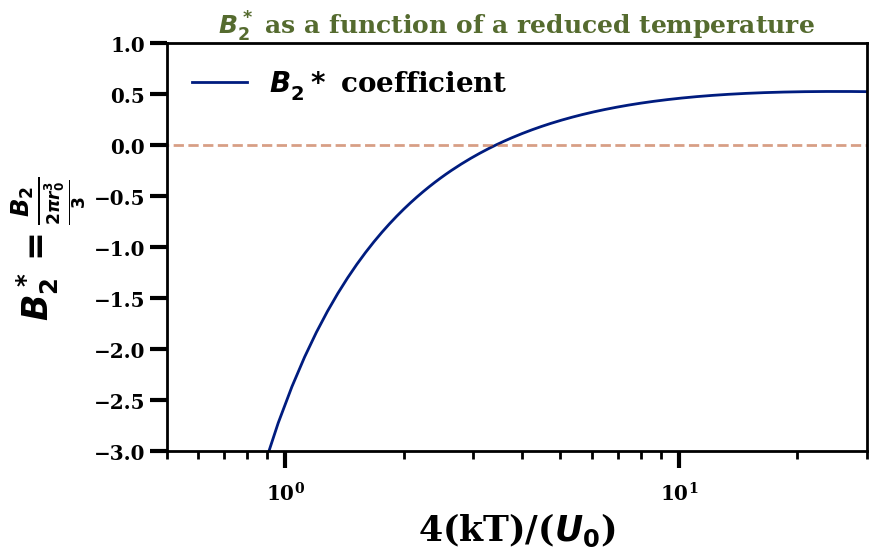

In [ ]:
#-------------------------------------------------------
#
# create a list for B2star and (4 * k T /U_{0} )
#
kToverU0=[]
B2star=[]
xx=0.1
b2resultsforlj = open("b2resultsforlj.txt", 'w') # open file to store results
while xx < 8.5:
    kToverU0.append(4.*xx)#  \int _ {x_0} ^{x_1} f(x) dx = integrate.quad(f,x_0,x_1)[0]
    U0overKT=1./xx
# integrate.quad solves one-dimensional integrals
#  \int _ {x_0} ^{x_1} f(x) dx = integrate.quad(f,x_0,x_1)[0]
    koed=integrate.quad(b2lj,0.,10.)[0]
    yy=4.*xx
    txt = str(yy)+ "\t" + str(koed) + "\n"
    b2resultsforlj.write(txt) # write results to file#
    B2star.append(koed)
    xx=xx+0.02
b2resultsforlj.close() # close the file with the stored results

# create the plot of $B_2^*$

b2d=np.array(B2star)
myfig=pl.figure(figsize=(10,6))
myfig.subplots_adjust(bottom=0.2,left=0.2)
ax  = myfig.add_subplot(111)
ax.plot(kToverU0,B2star, "-", linewidth=2, label=r'$B_2^ *$ coefficient')
ax.plot(kToverU0,b2d-b2d,"--",linewidth=2,alpha=0.5)
ax.set_xlabel(r'4(kT)/($U_{0}$)',fontsize=25,weight='bold')
ax.set_ylabel(r'$B_2^* = \frac{B_2}{\frac{2 \pi r_0^3}{3}}$',fontsize=25)
# log scale for the x axis
ax.set_xscale("log")
# ranges for the x and y axis
ax.set_xlim([0.5,30.])
ax.set_ylim([-3.0,1.])
ax.set_title(r'$B_2^*$ as a function of a reduced temperature',color='darkolivegreen',fontsize=18,weight='bold')
ax.legend(frameon=False,fontsize=20,ncol=1,loc='best')
pl.show()


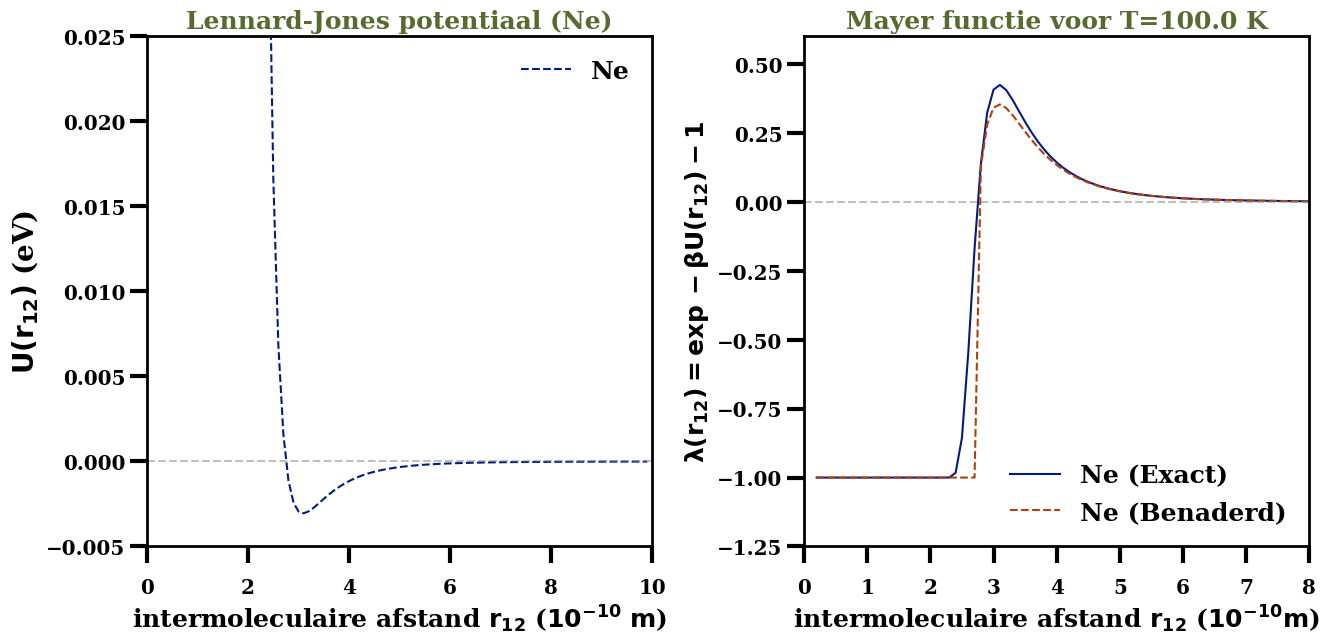

In [ ]:
# create the plot with the lambda (r_{12}) function (Mayer function) for a given temperature ...
#
selec=1 # select the molecule ...
kB= 8.617333262145e-05 # Boltzmann's constant in eV . K^{-1}
Temp=100. # temperature in Kelvin
rrange=np.arange(0.2,10,0.1)


figLJb=pl.figure(figsize=(15,7.5))
axLJb=figLJb.add_subplot(122)
axLJbb=figLJb.add_subplot(121)

axLJb.axis([0.,8.,-1.25,0.6])
axLJbb.axis([0.,10.,-0.005,0.025])
figLJb.subplots_adjust(bottom=0.2,wspace=0.3) # create room for x-axis label and blank spaces between subplots
ur12=(LennardJones(U0L[selec],r0L[selec],rrange))/(-1.*kB*Temp) # for Ne ...
lamr12=np.exp(ur12)-1
axLJb.plot(rrange,lamr12,lines[0],label="Ne (Exact)")
axLJbb.plot(rrange,LennardJones(U0L[selec],r0L[selec],rrange),lines[selec],label='Ne')
for jj in range(len(rrange)):
  if rrange[jj] < r0L[selec] : ur12[jj] = -1.

axLJbb.set_xlabel(r"intermoleculaire afstand $\bf r_{12}$ ($\bf 10^{-10}~m$)",fontsize=18, weight='bold')
axLJbb.set_ylabel(r"$\bf U\left(r_{12}\right)$ (eV)",fontsize=20, weight='bold')
axLJbb.set_title(r"Lennard-Jones potentiaal (Ne)",color='darkolivegreen',fontsize=18,weight='bold')
axLJbb.legend(frameon=False,fontsize=18,ncol=1,loc='best')
axLJbb.axhline(y=0.,color='grey',linestyle='dashed',alpha=0.5)

axLJb.plot(rrange,ur12,lines[1],label="Ne (Benaderd)")
axLJb.legend(frameon=False,fontsize=18,ncol=1,loc='best')
axLJb.set_xlabel(r"intermoleculaire afstand $\bf r_{12}$ ($\bf 10^{-10} m$)",fontsize=18,weight='bold')
axLJb.set_ylabel(r"$ \bf \lambda \left(r_{12}\right)=\exp - \beta U(r_{12}) - 1$",fontsize=18)
axLJb.set_title(r"Mayer functie voor T={} K".format(str(Temp)),color='darkolivegreen',fontsize=18,weight='bold')
axLJb.axhline(y=0.,color='grey',linestyle='dashed',alpha=0.5)

figLJb.savefig("LambdaLJ.eps",dpi=600)

## $\color{orange}{\text{6.6 Maxwell snelheidsdistributie en energiedistributie}}$

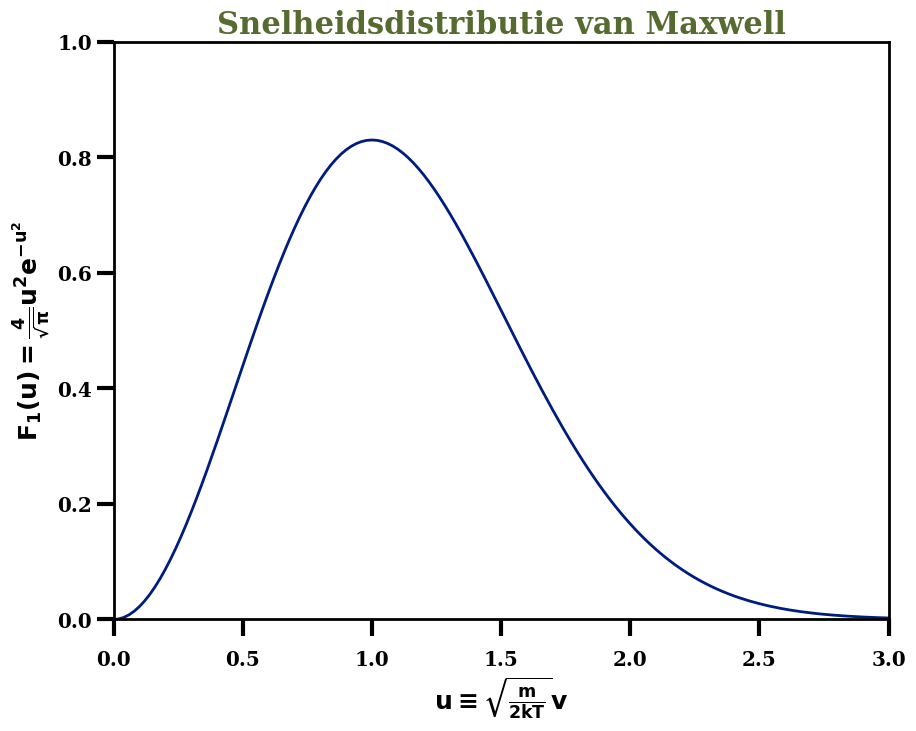

In [ ]:
# snelheidsdistributie van Maxwell in dimensieloze eenheden
figm=pl.figure(figsize=(10,7.5))
figm.tight_layout()
axm=figm.add_subplot(111)
axm.axis([0.,3.,0.,1])
urange=np.arange(0.0,3.+0.02,0.02)
uran2=np.power(urange,2.)

F1u=np.multiply(uran2,np.exp(-uran2))*4./np.power(np.pi,0.5)

axm.set_xlabel(r"$\bf u \equiv \sqrt{\frac{m}{2k T}} v$",fontsize=18, weight='bold')
axm.set_ylabel(r"$\bf F_1(u) = \frac {4} {\sqrt{\pi}} u^2 e ^{- u ^{2}}$",fontsize=18, weight='bold')
axm.set_title(r"Snelheidsdistributie van Maxwell",color='darkolivegreen',fontsize=22,weight='bold')
axm.plot(urange,F1u,lines[0],linewidth=2)
figm.savefig("MaxSnelDis.eps",dpi=600)

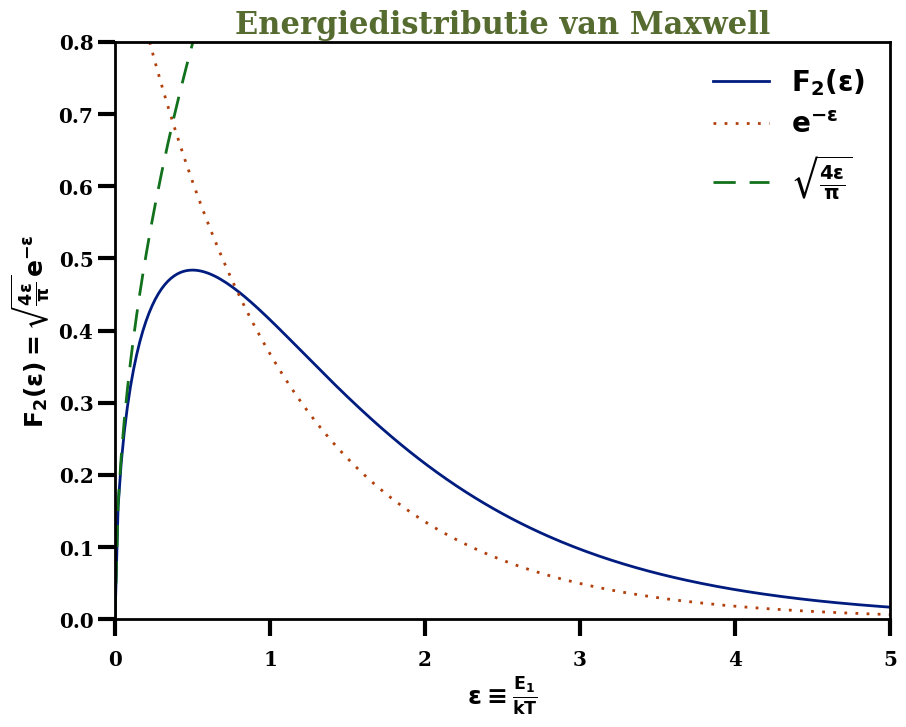

In [ ]:
# snelheidsdistributie van Maxwell in dimensieloze eenheden
fign=pl.figure(figsize=(10,7.5))
fign.tight_layout()
axn=fign.add_subplot(111)
axn.axis([0.,5.,0.,0.8])
erange=np.arange(0.0,5.+0.02,0.02)
sqerange=np.power(erange,0.5)*2./np.power(np.pi,0.5)

F2e=np.multiply(sqerange,np.exp(-erange))

axn.set_xlabel(r"$\bf \epsilon \equiv \frac{E_1} {kT}$",fontsize=18, weight='bold')
axn.set_ylabel(r"$\bf F_2(\epsilon) = \sqrt{ \frac {4 \epsilon} {\pi} }  e ^{- \epsilon}$",fontsize=18, weight='bold')
axn.set_title(r"Energiedistributie van Maxwell",color='darkolivegreen',fontsize=22,weight='bold')
axn.plot(erange,F2e,lines[0],linewidth=2,label=r"$\bf F_2(\epsilon)$")
axn.plot(erange,np.exp(-erange),dashes=[1,3],linewidth=2,label=r"$\bf e^{- \epsilon}$")
axn.plot(erange,sqerange,dashes=[8,5],linewidth=2,label=r"$\bf \sqrt{ \frac {4 \epsilon} {\pi} }$")
axn.legend(frameon=False,fontsize=20,ncol=1,loc='best')
fign.savefig("MaxEnerDis.eps",dpi=600)

## $\color{orange}{\text{6.5 Translationele entropie van een klassiek gas (Boltzmann gas)}}$

In drie dimensies:

$
\frac {S_{tr}} {Nk} =
 \left[ \ln \frac{V} {N} + \frac {3} {2} \ln T + \frac {5} {2}
+ \frac {3} {2} \ln \frac {2 \pi m k} {h^2} \right] = \frac {5} {2}
+ \ln \frac { 1 } {\rho \lambda ^ {3}} $

met $\rho = \frac {N} {V}$ (deeltjesdichtheid) en $\lambda = \sqrt {\frac{h^2} {2 \pi m k T}}$ (thermische golflengte)

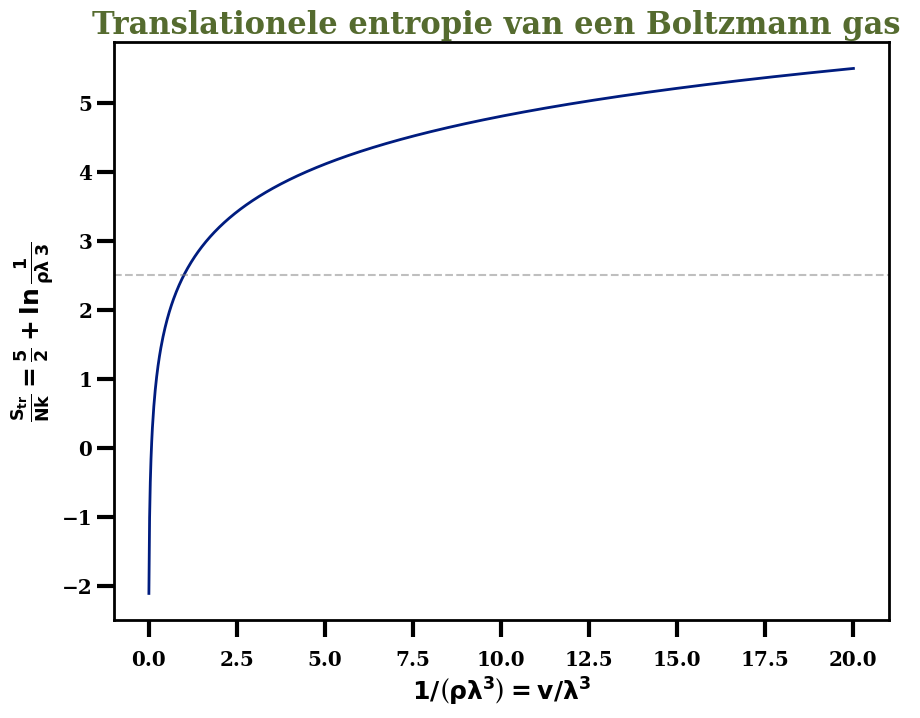

In [ ]:
figs=pl.figure(figsize=(10,7.5))
figs.tight_layout()
axs=figs.add_subplot(111)
#axs.axis([0.,5.,0.,0.8])
oneover=np.arange(0.01,20.+0.02,0.02)
Str=2.5+np.log(oneover)

axs.set_xlabel(r"$\bf 1 / \left( \rho \lambda ^3 \right) = v / \lambda ^3 $",fontsize=18, weight='bold')
axs.set_ylabel(r"$\bf \frac{S_{tr}}{Nk} = \frac {5} {2} + \ln \frac { 1 } {\rho \lambda ^ {3}} $",fontsize=18, weight='bold')
axs.set_title(r"Translationele entropie van een Boltzmann gas ",color='darkolivegreen',fontsize=22,weight='bold')
axs.plot(oneover,Str,lines[0],linewidth=2)
axs.axhline(y=2.5,color='grey',linestyle='dashed',alpha=0.5)
figs.savefig("SackurTetrode.eps",dpi=1200)